In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)

In [20]:
print("PyTorch version:", torch.__version__)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using device:", device)

PyTorch version: 2.13.0+cpu
Using device: cpu


In [21]:
np.random.seed(42)
torch.manual_seed(42)

In [22]:
df = pd.read_csv("../data/diabetes.csv")

df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72.0,35,169.5,33.6,0.627,50,1
1,1,85,66.0,29,102.5,26.6,0.351,31,0
2,8,183,64.0,32,169.5,23.3,0.672,32,1
3,1,89,66.0,23,94.0,28.1,0.167,21,0
4,0,137,40.0,35,168.0,43.1,2.288,33,1


In [23]:
print("Dataset shape:", df.shape)

print("\nClass distribution:")
print(df["Outcome"].value_counts())

print("\nMissing values:")
print(df.isnull().sum())

Dataset shape: (768, 9)

Class distribution:
Outcome
0    500
1    268
Name: count, dtype: int64

Missing values:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


In [24]:
zero_columns = [
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI"
]

df[zero_columns] = df[zero_columns].replace(0, np.nan)
X = df.drop("Outcome", axis=1)
y = df["Outcome"]
# First: 70% training and 30% temporary
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

# Split remaining 30% into 15% validation and 15% test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

print("Training shape:", X_train.shape)
print("Validation shape:", X_val.shape)
print("Test shape:", X_test.shape)
train_medians = X_train.median()

X_train = X_train.fillna(train_medians)
X_val = X_val.fillna(train_medians)
X_test = X_test.fillna(train_medians)
scaler = StandardScaler()

# Learn mean and standard deviation ONLY from training data
X_train_scaled = scaler.fit_transform(X_train)

# Use the same training statistics
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)


Training shape: (537, 8)
Validation shape: (115, 8)
Test shape: (116, 8)


In [25]:
X_train_tensor = torch.tensor(
    X_train_scaled,
    dtype=torch.float32
)

y_train_tensor = torch.tensor(
    y_train.values,
    dtype=torch.float32
).view(-1, 1)


X_val_tensor = torch.tensor(
    X_val_scaled,
    dtype=torch.float32
)

y_val_tensor = torch.tensor(
    y_val.values,
    dtype=torch.float32
).view(-1, 1)


X_test_tensor = torch.tensor(
    X_test_scaled,
    dtype=torch.float32
)

y_test_tensor = torch.tensor(
    y_test.values,
    dtype=torch.float32
).view(-1, 1)


print("X_train:", X_train_tensor.shape)
print("y_train:", y_train_tensor.shape)

X_train: torch.Size([537, 8])
y_train: torch.Size([537, 1])


In [26]:
train_dataset = TensorDataset(
    X_train_tensor,
    y_train_tensor
)

val_dataset = TensorDataset(
    X_val_tensor,
    y_val_tensor
)

test_dataset = TensorDataset(
    X_test_tensor,
    y_test_tensor
)

In [27]:
batch_size = 32

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False
)

X_batch, y_batch = next(iter(train_loader))

print("X batch shape:", X_batch.shape)
print("y batch shape:", y_batch.shape)

X batch shape: torch.Size([32, 8])
y batch shape: torch.Size([32, 1])


In [28]:
class DiabetesMLP(nn.Module):

    def __init__(self):
        super(DiabetesMLP, self).__init__()

        self.network = nn.Sequential(

            nn.Linear(8, 8),
            nn.ReLU(),

            nn.Linear(8, 1)
        )

    def forward(self, x):
        return self.network(x)
model = DiabetesMLP().to(device)

print(model)

DiabetesMLP(
  (network): Sequential(
    (0): Linear(in_features=8, out_features=8, bias=True)
    (1): ReLU()
    (2): Linear(in_features=8, out_features=1, bias=True)
  )
)


In [29]:
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)
epochs = 100

train_losses = []
val_losses = []

start_time = time.time()

for epoch in range(epochs):

   
    # TRAINING MODE
    model.train()

    running_train_loss = 0.0

    for X_batch, y_batch in train_loader:

        # Move batch to device
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        # Forward propagation
        outputs = model(X_batch)

        # Calculate loss
        loss = criterion(outputs, y_batch)

        # Clear old gradients
        optimizer.zero_grad()

        # Backpropagation
        loss.backward()

        # Update weights
        optimizer.step()

        running_train_loss += loss.item() * X_batch.size(0)

    # Average training loss
    epoch_train_loss = running_train_loss / len(train_dataset)


    
    # VALIDATION MODE
  
    model.eval()

    running_val_loss = 0.0

    with torch.no_grad():

        for X_batch, y_batch in val_loader:

            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            outputs = model(X_batch)

            loss = criterion(outputs, y_batch)

            running_val_loss += loss.item() * X_batch.size(0)

    # Average validation loss
    epoch_val_loss = running_val_loss / len(val_dataset)


    # Store losses
    train_losses.append(epoch_train_loss)
    val_losses.append(epoch_val_loss)


    # Print progress
    if (epoch + 1) % 10 == 0:

        print(
            f"Epoch [{epoch + 1}/{epochs}] | "
            f"Train Loss: {epoch_train_loss:.4f} | "
            f"Val Loss: {epoch_val_loss:.4f}"
        )


training_time_pytorch = time.time() - start_time

print("\nTraining completed!")
print(f"Training time: {training_time_pytorch:.4f} seconds")

Epoch [10/100] | Train Loss: 0.5821 | Val Loss: 0.5963
Epoch [20/100] | Train Loss: 0.4671 | Val Loss: 0.5212
Epoch [30/100] | Train Loss: 0.4304 | Val Loss: 0.5125
Epoch [40/100] | Train Loss: 0.4133 | Val Loss: 0.5129
Epoch [50/100] | Train Loss: 0.4004 | Val Loss: 0.5087
Epoch [60/100] | Train Loss: 0.3886 | Val Loss: 0.5002
Epoch [70/100] | Train Loss: 0.3757 | Val Loss: 0.4863
Epoch [80/100] | Train Loss: 0.3636 | Val Loss: 0.4739
Epoch [90/100] | Train Loss: 0.3520 | Val Loss: 0.4635
Epoch [100/100] | Train Loss: 0.3426 | Val Loss: 0.4524

Training completed!
Training time: 1.8549 seconds


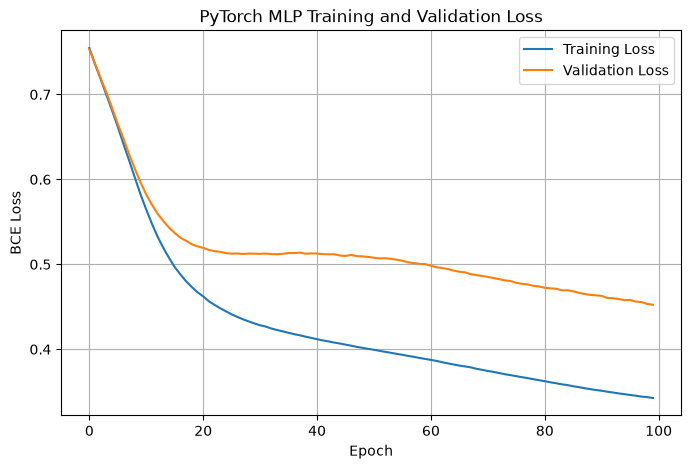

In [30]:
plt.figure(figsize=(8, 5))

plt.plot(train_losses, label="Training Loss")
plt.plot(val_losses, label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("BCE Loss")
plt.title("PyTorch MLP Training and Validation Loss")

plt.legend()
plt.grid()

plt.show()

In [31]:
def evaluate_pytorch(model, X_tensor, y_true, dataset_name):

    model.eval()

    X_tensor = X_tensor.to(device)

    with torch.no_grad():
        logits = model(X_tensor)

        # Convert logits to probabilities
        probabilities = torch.sigmoid(logits)

        # Probability to class prediction
        predictions = (probabilities >= 0.5).int()

    # Convert tensors to NumPy
    y_prob = probabilities.cpu().numpy().flatten()
    y_pred = predictions.cpu().numpy().flatten()

    # Metrics
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, zero_division=0)
    recall = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    auc = roc_auc_score(y_true, y_prob)

    print(f"\n----- PyTorch MLP {dataset_name} Results -----")
    print(f"Accuracy : {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall   : {recall:.4f}")
    print(f"F1 Score : {f1:.4f}")
    print(f"ROC-AUC  : {auc:.4f}")

    print("\nConfusion Matrix:")
    print(confusion_matrix(y_true, y_pred))

    return {
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "auc": auc
    }

In [32]:
val_results_pytorch = evaluate_pytorch(
    model,
    X_val_tensor,
    y_val.values,
    "Validation"
)
test_results_pytorch = evaluate_pytorch(
    model,
    X_test_tensor,
    y_test.values,
    "Test"
)


----- PyTorch MLP Validation Results -----
Accuracy : 0.7739
Precision: 0.6591
Recall   : 0.7250
F1 Score : 0.6905
ROC-AUC  : 0.8503

Confusion Matrix:
[[60 15]
 [11 29]]

----- PyTorch MLP Test Results -----
Accuracy : 0.8793
Precision: 0.8857
Recall   : 0.7561
F1 Score : 0.8158
ROC-AUC  : 0.9421

Confusion Matrix:
[[71  4]
 [10 31]]


In [33]:
torch.manual_seed(42)

model_lr_experiment = DiabetesMLP().to(device)

criterion_lr = nn.BCEWithLogitsLoss()

optimizer_lr = torch.optim.Adam(
    model_lr_experiment.parameters(),
    lr=0.01
)
epochs = 100

lr_train_losses = []
lr_val_losses = []

for epoch in range(epochs):

    # Training
    model_lr_experiment.train()
    running_train_loss = 0.0

    for X_batch, y_batch in train_loader:

        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        outputs = model_lr_experiment(X_batch)
        loss = criterion_lr(outputs, y_batch)

        optimizer_lr.zero_grad()
        loss.backward()
        optimizer_lr.step()

        running_train_loss += loss.item() * X_batch.size(0)

    epoch_train_loss = running_train_loss / len(train_dataset)


    # Validation
    model_lr_experiment.eval()
    running_val_loss = 0.0

    with torch.no_grad():

        for X_batch, y_batch in val_loader:

            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            outputs = model_lr_experiment(X_batch)
            loss = criterion_lr(outputs, y_batch)

            running_val_loss += loss.item() * X_batch.size(0)

    epoch_val_loss = running_val_loss / len(val_dataset)

    lr_train_losses.append(epoch_train_loss)
    lr_val_losses.append(epoch_val_loss)

    if (epoch + 1) % 10 == 0:
        print(
            f"Epoch [{epoch+1}/{epochs}] | "
            f"Train Loss: {epoch_train_loss:.4f} | "
            f"Val Loss: {epoch_val_loss:.4f}"
        )

Epoch [10/100] | Train Loss: 0.3766 | Val Loss: 0.4884
Epoch [20/100] | Train Loss: 0.3369 | Val Loss: 0.4493
Epoch [30/100] | Train Loss: 0.3191 | Val Loss: 0.4710
Epoch [40/100] | Train Loss: 0.3067 | Val Loss: 0.4789
Epoch [50/100] | Train Loss: 0.2977 | Val Loss: 0.5050
Epoch [60/100] | Train Loss: 0.2950 | Val Loss: 0.5280
Epoch [70/100] | Train Loss: 0.2943 | Val Loss: 0.5300
Epoch [80/100] | Train Loss: 0.2905 | Val Loss: 0.5467
Epoch [90/100] | Train Loss: 0.2881 | Val Loss: 0.5469
Epoch [100/100] | Train Loss: 0.2847 | Val Loss: 0.5460


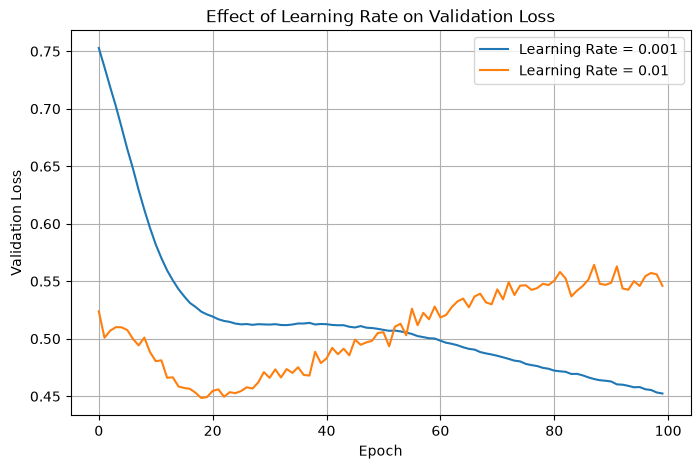

Model saved successfully!


In [34]:
plt.figure(figsize=(8, 5))

plt.plot(val_losses, label="Learning Rate = 0.001")
plt.plot(lr_val_losses, label="Learning Rate = 0.01")

plt.xlabel("Epoch")
plt.ylabel("Validation Loss")
plt.title("Effect of Learning Rate on Validation Loss")

plt.legend()
plt.grid()

plt.show()
torch.save(
    model.state_dict(),
    "../model/diabetes_mlp.pth"
)

print("Model saved successfully!")

In [ ]:
comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "NumPy MLP",
        "PyTorch MLP"
    ],

    "Accuracy": [
        0.8017,
        0.7931,
        test_results_pytorch["accuracy"]
    ],

    "Precision": [
        0.7812,
        0.7429,
        test_results_pytorch["precision"]
    ],

    "Recall": [
        0.6098,
        0.6341,
        test_results_pytorch["recall"]
    ],

    "F1 Score": [
        0.6849,
        0.6842,
        test_results_pytorch["f1"]
    ],

    "ROC-AUC": [
        0.9076,
        0.8920,
        test_results_pytorch["auc"]
    ]
})

comparison.to_csv("../output/model_comparison.csv", index=False)

print("Comparison table saved successfully!")

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.80170,0.781200,0.609800,0.684900,0.907600
1,NumPy MLP,0.79310,0.742900,0.634100,0.684200,0.892000
2,PyTorch MLP,0.87931,0.885714,0.756098,0.815789,0.942114


In [36]:
import os
import joblib

os.makedirs("../model", exist_ok=True)

torch.save(
    model.state_dict(),
    "../model/diabetes_mlp.pth"
)

joblib.dump(
    scaler,
    "../model/scaler.pkl"
)

joblib.dump(
    train_medians,
    "../model/train_medians.pkl"
)

print("Model, scaler and medians saved successfully!")

Model, scaler and medians saved successfully!
